Modeled Erosion Rates - HYPOTHETICAL (CT-5 = CT-6 erosion rate)
CT-1: 22.9001 ± 1.8595
CT-2: 94.8251 ± 7.7192
CT-3: 29.5013 ± 2.4127
CT-4: 29.6089 ± 2.4398
CT-5 (HYPOTHETICAL): 29.8014 ± 2.4314
CT-6: 29.7974 ± 2.4379
CT-7: 532.0599 ± 51.9161
CT-8: 262.9337 ± 22.8529
CT-9: 104.9995 ± 8.5575
CT-10: 245.8417 ± 21.3102
CT-11: 286.0629 ± 24.5662

Synthetic CT-8 (flux-weighted CT-5_hyp + CT-6):
CT-8 synthetic: 24.4941 ± 1.4636
CT-8 measured:  263.0000 ± 22.9000

Synthetic CT-9 (flux-weighted CT-8_syn + CT-3):
CT-9 synthetic: 25.4995 ± 1.2665
CT-9 measured:  105.0000 ± 8.5500

Quartz Fertility: CT-5_hyp + CT-6 → CT-8_synthetic
Positive Q samples: 66175/100000 (66.2%)
Qb/Qa (CT-6/CT-5) Fertility ratio (median, (25-75% range)): 0.1980 (0.1102 - 0.2843)
Qa/Qb (CT-5/CT-6) Fertility ratio (median, (25-75% range)): 5.0495 (3.5175 - 9.0727)

Quartz Fertility: CT-8_syn + CT-3 → CT-9_synthetic
Positive Q samples: 100000/100000 (100.0%)
Qb/Qa (CT-3/CT-8) Fertility ratio (median, (25-75% range)): 1.0740

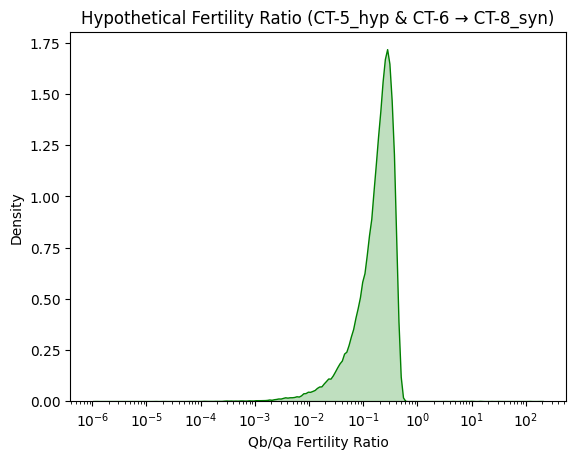

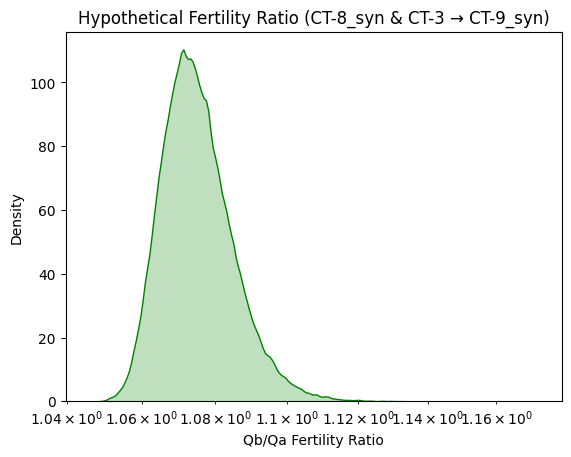

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

# Load Excel file into a DataFrame 
df = pd.read_excel('/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx') 

np.random.seed(17)
number_samples = 100000

# ============================================================
# Hypothetical erosion rate samples
# CT-5 assigned CT-6 erosion rate and uncertainty
# All others use their own measured values
# ============================================================
print("Modeled Erosion Rates - HYPOTHETICAL (CT-5 = CT-6 erosion rate)")
erosion_samples = {}
for i in range(11):
    site_name = f"CT-{i+1}"
    if site_name == 'CT-5':
        samples = np.random.normal(df.loc[5, 'Erosion_rate'],
                                   df.loc[5, 'Erosion_rate_uncertainty_external'],
                                   number_samples)
        print(f"{site_name} (HYPOTHETICAL): {np.median(samples):6.4f} ± {np.std(samples):6.4f}")
    else:
        samples = np.random.normal(df.loc[i, 'Erosion_rate'],
                                   df.loc[i, 'Erosion_rate_uncertainty_external'],
                                   number_samples)
        print(f"{site_name}: {np.median(samples):6.4f} ± {np.std(samples):6.4f}")
    erosion_samples[site_name] = samples

CT_3_samples = erosion_samples['CT-3']
CT_5_samples = erosion_samples['CT-5']
CT_6_samples = erosion_samples['CT-6']

# ============================================================
# Synthetic CT-8: flux-weighted mix of CT-5_hyp + CT-6
# E_CT8 = (E_CT5 * A_CT5 + E_CT6 * A_CT6) / A_CT8
# ============================================================
A_5 = df.loc[4, 'Source_Area']
A_6 = df.loc[5, 'Source_Area']
A_8 = df.loc[7, 'Source_Area']

CT_8_synthetic = (CT_5_samples * A_5 + CT_6_samples * A_6) / A_8

print("\nSynthetic CT-8 (flux-weighted CT-5_hyp + CT-6):")
print(f"CT-8 synthetic: {np.median(CT_8_synthetic):6.4f} ± {np.std(CT_8_synthetic):6.4f}")
print(f"CT-8 measured:  {df.loc[7, 'Erosion_rate']:6.4f} ± {df.loc[7, 'Erosion_rate_uncertainty_external']:6.4f}")

# ============================================================
# Synthetic CT-9: flux-weighted mix of CT-8_syn + CT-3
# Using A_b = (A_CT9 - A_CT8) for CT-3 side area (matching original notebook)
# E_CT9 = (E_CT8 * A_CT8 + E_CT3 * A_b) / A_CT9
# ============================================================
A_9 = df.loc[8, 'Source_Area']
A_b_ct9 = A_9 - A_8  # area attributed to CT-3 side

CT_9_synthetic = (CT_8_synthetic * A_8 + CT_3_samples * A_b_ct9) / A_9

print("\nSynthetic CT-9 (flux-weighted CT-8_syn + CT-3):")
print(f"CT-9 synthetic: {np.median(CT_9_synthetic):6.4f} ± {np.std(CT_9_synthetic):6.4f}")
print(f"CT-9 measured:  {df.loc[8, 'Erosion_rate']:6.4f} ± {df.loc[8, 'Erosion_rate_uncertainty_external']:6.4f}")

# ============================================================
# Quartz fertility: CT-5_hyp + CT-6 → CT-8_synthetic
# ============================================================
A_a = df.loc[4, 'Source_Area']
P_a = df.loc[4, 'Surface_Production_Rate']
E_a = CT_5_samples

A_b = df.loc[5, 'Source_Area']
P_b = df.loc[5, 'Surface_Production_Rate']
E_b = CT_6_samples

A_c = df.loc[7, 'Source_Area']
P_c = df.loc[7, 'Surface_Production_Rate']
E_c = CT_8_synthetic

Q = (P_c * E_a * A_a - P_a * E_c * A_a) / (P_b * E_c * A_b - P_c * E_b * A_b)
Qi = 1.0 / Q
i_f2 = np.where(Q > 0)
i_f3 = np.where(Qi > 0)

plt.figure()
sns.kdeplot(Q[i_f2], bw_adjust=.5, fill=True, color="green", log_scale=True)
plt.xlabel("Qb/Qa Fertility Ratio")
plt.ylabel("Density")
plt.title("Hypothetical Fertility Ratio (CT-5_hyp & CT-6 → CT-8_syn)")

print("\nQuartz Fertility: CT-5_hyp + CT-6 → CT-8_synthetic")
print(f"Positive Q samples: {len(Q[i_f2])}/{number_samples} ({100*len(Q[i_f2])/number_samples:.1f}%)")
print("Qb/Qa (CT-6/CT-5) Fertility ratio (median, (25-75% range)): {0:6.4f} ({2:6.4f} - {1:6.4f})".format(
    np.median(Q[i_f2]), np.percentile(Q[i_f2], 75), np.percentile(Q[i_f2], 25)))
print("Qa/Qb (CT-5/CT-6) Fertility ratio (median, (25-75% range)): {0:6.4f} ({2:6.4f} - {1:6.4f})".format(
    np.median(Qi[i_f3]), np.percentile(Qi[i_f3], 75), np.percentile(Qi[i_f3], 25)))

# ============================================================
# Quartz fertility: CT-8_syn + CT-3 → CT-9_synthetic
# ============================================================
A_a2 = df.loc[7, 'Source_Area']
P_a2 = df.loc[7, 'Surface_Production_Rate']
E_a2 = CT_8_synthetic

A_b2 = A_9 - A_8  # (CT-9 - CT-8) matching original notebook
P_b2 = df.loc[2, 'Surface_Production_Rate']
E_b2 = CT_3_samples

A_c2 = df.loc[8, 'Source_Area']
P_c2 = df.loc[8, 'Surface_Production_Rate']
E_c2 = CT_9_synthetic

Q_9 = (P_c2 * E_a2 * A_a2 - P_a2 * E_c2 * A_a2) / (P_b2 * E_c2 * A_b2 - P_c2 * E_b2 * A_b2)
Qi_9 = 1.0 / Q_9
i_f4 = np.where(Q_9 > 0)
i_f5 = np.where(Qi_9 > 0)

plt.figure()
sns.kdeplot(Q_9[i_f4], bw_adjust=.5, fill=True, color="green", log_scale=True)
plt.xlabel("Qb/Qa Fertility Ratio")
plt.ylabel("Density")
plt.title("Hypothetical Fertility Ratio (CT-8_syn & CT-3 → CT-9_syn)")

print("\nQuartz Fertility: CT-8_syn + CT-3 → CT-9_synthetic")
print(f"Positive Q samples: {len(Q_9[i_f4])}/{number_samples} ({100*len(Q_9[i_f4])/number_samples:.1f}%)")
print("Qb/Qa (CT-3/CT-8) Fertility ratio (median, (25-75% range)): {0:6.4f} ({2:6.4f} - {1:6.4f})".format(
    np.median(Q_9[i_f4]), np.percentile(Q_9[i_f4], 75), np.percentile(Q_9[i_f4], 25)))
print("Qa/Qb (CT-8/CT-3) Fertility ratio (median, (25-75% range)): {0:6.4f} ({2:6.4f} - {1:6.4f})".format(
    np.median(Qi_9[i_f5]), np.percentile(Qi_9[i_f5], 75), np.percentile(Qi_9[i_f5], 25)))

plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import csv

# Load Excel file into a DataFrame 
df = pd.read_excel('/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx') 

np.random.seed(17)
number_samples = 100000
num_samples_zircon = 10000

# ============================================================
# Hypothetical erosion rate samples
# CT-5 assigned CT-6 erosion rate and uncertainty
# ============================================================
print("Modeled Erosion Rates - HYPOTHETICAL (CT-5 = CT-6 erosion rate)")
erosion_samples = {}
for i in range(11):
    site_name = f"CT-{i+1}"
    if site_name == 'CT-5':
        samples = np.random.normal(df.loc[5, 'Erosion_rate'],
                                   df.loc[5, 'Erosion_rate_uncertainty_external'],
                                   number_samples)
        print(f"{site_name} (HYPOTHETICAL): {np.median(samples):6.4f} ± {np.std(samples):6.4f}")
    else:
        samples = np.random.normal(df.loc[i, 'Erosion_rate'],
                                   df.loc[i, 'Erosion_rate_uncertainty_external'],
                                   number_samples)
        print(f"{site_name}: {np.median(samples):6.4f} ± {np.std(samples):6.4f}")
    erosion_samples[site_name] = samples

CT_3_samples = erosion_samples['CT-3']
CT_5_samples = erosion_samples['CT-5']
CT_6_samples = erosion_samples['CT-6']

# ============================================================
# Synthetic CT-8: flux-weighted mix of CT-5_hyp + CT-6
# ============================================================
A_5 = df.loc[4, 'Source_Area']
A_6 = df.loc[5, 'Source_Area']
A_8 = df.loc[7, 'Source_Area']

CT_8_synthetic = (CT_5_samples * A_5 + CT_6_samples * A_6) / A_8

print(f"\nCT-8 synthetic: {np.median(CT_8_synthetic):6.4f} ± {np.std(CT_8_synthetic):6.4f}")

# ============================================================
# Definition for calculating zircon fertility ratios (2 to 1)
# Copied from original notebook
# ============================================================
def calculate_zircon_fertility_ratios2_to_1(csv_filename, sample_a_key, sample_b_key, 
                                          erosion_samples, df, wct_a, wct_b, 
                                          sample_a_index, sample_b_index,
                                          num_samples=10000, random_seed=17):
    np.random.seed(random_seed)
    
    wct_a_list, wct_b_list = [], []
    with open(csv_filename, 'r') as file:
        csvfile = csv.reader(file)
        next(csvfile)
        for row in csvfile:
            wct_a_val = float(row[0])
            wct_b_val = float(row[1])
            if wct_a_val not in [0.0, 1.0] and wct_b_val not in [0.0, 1.0]:
                wct_a_list.append(wct_a_val)
                wct_b_list.append(wct_b_val)
    
    ratio = np.array(wct_a_list) / np.array(wct_b_list)
    
    if len(ratio) == 0:
        raise ValueError("No valid mixing coefficients found after filtering out 0s and 1s")
    
    np.random.seed(random_seed)
    ratio_samples = np.random.choice(ratio, replace=True, size=num_samples)
    
    ER_A_samples = erosion_samples[sample_a_key][:num_samples]
    ER_B_samples = erosion_samples[sample_b_key][:num_samples]
    
    WA_A = df.loc[sample_a_index, 'Source_Area']
    WA_B = df.loc[sample_b_index, 'Source_Area']

    print(f"Calculation parameters:")
    print(f"Number of valid coefficient pairs after filtering: {len(wct_a_list)}")
    print(f"Source Areas - {sample_a_key}: {WA_A}, {sample_b_key}: {WA_B}")
    print(f"Median erosion rates - {sample_a_key}: {np.median(ER_A_samples):.4f}, {sample_b_key}: {np.median(ER_B_samples):.4f}")
    print(f"Input weight coefficients - {sample_a_key}: {wct_a:.4f}, {sample_b_key}: {wct_b:.4f}")
    print(f"Median ratio (wct_a/wct_b) from filtered data: {np.median(ratio_samples):.4f}")
    print(f"Random seed: {random_seed}, Number of samples: {num_samples}")
    print()
    
    ZA_ZB = ratio_samples/wct_b * ER_B_samples*WA_B / (ER_A_samples*WA_A)
    ZB_ZA = 1/ZA_ZB
    
    results = {
        'ZA_ZB_samples': ZA_ZB,
        'ZB_ZA_samples': ZB_ZA,
        'ZA_ZB_median': np.median(ZA_ZB),
        'ZB_ZA_median': np.median(ZB_ZA),
        'ZA_ZB_percentiles': (np.percentile(ZA_ZB, 25), np.percentile(ZA_ZB, 75)),
        'ZB_ZA_percentiles': (np.percentile(ZB_ZA, 25), np.percentile(ZB_ZA, 75))
    }
    
    return results

def print_fertility_results(results, sample_a_name, sample_b_name):
    print(f"Z{sample_a_name}/Z{sample_b_name} Ratio Analysis based on Monte Carlo simulations")
    print(f"Median Z{sample_b_name}/Z{sample_a_name}: {results['ZB_ZA_median']:6.4f}")
    print("Z{1}/Z{0} Fertility Ratio (median, (25-75% range)): {2:6.4f} ({4:6.4f} - {3:6.4f})".format(
        sample_a_name, sample_b_name,
        results['ZB_ZA_median'], 
        results['ZB_ZA_percentiles'][1], 
        results['ZB_ZA_percentiles'][0]
    ))
    print("Z{0}/Z{1} Fertility Ratio (median, (25-75% range)): {2:6.4f} ({4:6.4f} - {3:6.4f})".format(
        sample_a_name, sample_b_name,
        results['ZA_ZB_median'], 
        results['ZA_ZB_percentiles'][1], 
        results['ZA_ZB_percentiles'][0]
    ))

# ============================================================
# Zircon fertility: CT-5_hyp + CT-6 → CT-8.2_synthetic
# Using original mixing coefficients from notebook Cell 51
# ============================================================
print("\n" + "=" * 60)
print("ZIRCON FERTILITY: CT-5_hyp + CT-6 → CT-8.2_syn")
print("=" * 60)

csv_file = '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/Zircon/detritalPy_mix/Spreadsheets/mix_coeffs_all_ct-5_ct-6_to_ct-8.2.csv'
results_8 = calculate_zircon_fertility_ratios2_to_1(
    csv_filename=csv_file,
    sample_a_key='CT-5',
    sample_b_key='CT-6', 
    erosion_samples=erosion_samples,
    df=df,
    wct_a=0.559243657338644,
    wct_b=0.440756342661356,
    sample_a_index=4,
    sample_b_index=5,
    num_samples=num_samples_zircon,
    random_seed=17
)

print_fertility_results(results_8, 'CT-5', 'CT-6')

# ============================================================
# Zircon fertility: CT-8.2_syn + CT-3 → CT-9_synthetic
# Using original mixing coefficients from notebook Cell 63
# Need to pass synthetic CT-8 erosion samples
# ============================================================
print("\n" + "=" * 60)
print("ZIRCON FERTILITY: CT-8.2_syn + CT-3 → CT-9_syn")
print("=" * 60)

csv_file = '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/Zircon/detritalPy_mix/Spreadsheets/mix_coeffs_all_ct-8.2_ct-3_to_ct-9.csv'
results_9 = calculate_zircon_fertility_ratios2_to_1(
    csv_filename=csv_file,
    sample_a_key='CT-8',
    sample_b_key='CT-3', 
    erosion_samples={
        'CT-8': CT_8_synthetic,
        'CT-3': CT_3_samples
    },
    df=df,
    wct_a=0.830589798839197,
    wct_b=0.169410201160803,
    sample_a_index=7,
    sample_b_index=2,
    num_samples=num_samples_zircon,
    random_seed=17
)

print_fertility_results(results_9, 'CT-8', 'CT-3')

Modeled Erosion Rates - HYPOTHETICAL (CT-5 = CT-6 erosion rate)
CT-1: 22.9001 ± 1.8595
CT-2: 94.8251 ± 7.7192
CT-3: 29.5013 ± 2.4127
CT-4: 29.6089 ± 2.4398
CT-5 (HYPOTHETICAL): 29.8014 ± 2.4314
CT-6: 29.7974 ± 2.4379
CT-7: 532.0599 ± 51.9161
CT-8: 262.9337 ± 22.8529
CT-9: 104.9995 ± 8.5575
CT-10: 245.8417 ± 21.3102
CT-11: 286.0629 ± 24.5662

CT-8 synthetic: 24.4941 ± 1.4636

ZIRCON FERTILITY: CT-5_hyp + CT-6 → CT-8.2_syn
Calculation parameters:
Number of valid coefficient pairs after filtering: 5000
Source Areas - CT-5: 1495.897, CT-6: 2573.245
Median erosion rates - CT-5: 29.7708, CT-6: 29.8317
Input weight coefficients - CT-5: 0.5592, CT-6: 0.4408
Median ratio (wct_a/wct_b) from filtered data: 1.1378
Random seed: 17, Number of samples: 10000

ZCT-5/ZCT-6 Ratio Analysis based on Monte Carlo simulations
Median ZCT-6/ZCT-5: 0.2250
ZCT-6/ZCT-5 Fertility Ratio (median, (25-75% range)): 0.2250 (0.1622 - 0.3273)
ZCT-5/ZCT-6 Fertility Ratio (median, (25-75% range)): 4.4450 (3.0551 - 6.1649)


Hypothetical Quartz Fertility Qa/Qb (CT-8_syn/CT-3): 0.9311 (0.9253 - 0.9362)
Hypothetical Zircon Fertility Za/Zb (CT-8_syn/CT-3): 1.7915 (1.2660 - 2.7728)
HYPOTHETICAL PALEO EROSION RATES

CT-Ter-2:
  E_A (CT-8): 48.61 (39.51-57.49) m/Myr
  E_B (CT-3): 1059.08 (843.73-1280.89) m/Myr
  Valid solutions: 100000/100000 (100.0%)

CT-Ter-10:
  E_A (CT-8): 30.06 (24.13-36.03) m/Myr
  E_B (CT-3): 742.13 (598.38-887.71) m/Myr
  Valid solutions: 100000/100000 (100.0%)


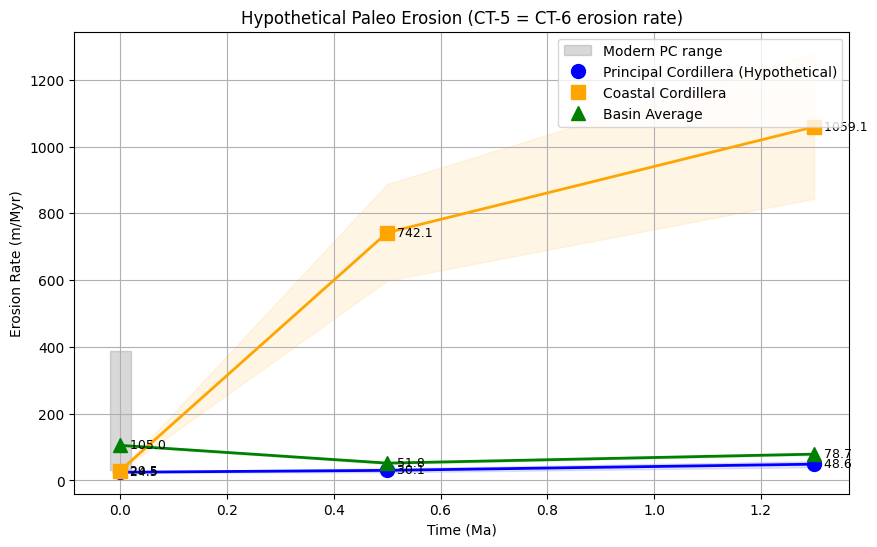

Principal Cordillera - Hypothetical (Blue):
Time (Ma) | Median (m/Myr) | Lower bound | Upper bound
------------------------------------------------------------
    1.30 |           48.6 |        39.5 |        57.5
    0.50 |           30.1 |        24.1 |        36.0
    0.00 |           24.5 |        23.0 |        26.0


Coastal Cordillera (Orange):
Time (Ma) | Median (m/Myr) | Lower bound | Upper bound
------------------------------------------------------------
    1.30 |         1059.1 |       843.7 |      1280.9
    0.50 |          742.1 |       598.4 |       887.7
    0.00 |           29.5 |        28.9 |        30.1


Basin Average (Green):
Time (Ma) | Median (m/Myr) | Lower bound | Upper bound
------------------------------------------------------------
    1.30 |           78.7 |        75.9 |        81.5
    0.50 |           51.8 |        49.0 |        54.6
    0.00 |          105.0 |       103.0 |       107.0


In [3]:
# ============================================================
# Hypothetical Paleo Erosion Calculations
# Run AFTER the hypothetical quartz and zircon fertility scripts
# Uses: CT_8_synthetic, Q_8, Qi_8, Q_9, Qi_9, results_8, results_9
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

excel_file = '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx'
df = pd.read_excel(excel_file)

# ============================================================
# Paleo erosion rates from CRONUS (unchanged)
# ============================================================
E_c_Ter2_mean = 78.7
E_c_Ter2_std  = 2.8
E_c_Ter10_mean = 51.8
E_c_Ter10_std  = 2.77

# ============================================================
# Hypothetical quartz fertility Q_A/Q_B (CT-8/CT-3)
# Qa/Qb from the CT-8_syn + CT-3 → CT-9_syn calculation
# Pull median and IQR from Qi_9 (positive values only)
# ============================================================
i_f5 = np.where(Qi_9 > 0)
Q_median = np.median(Qi_9[i_f5])
Q_q1     = np.percentile(Qi_9[i_f5], 25)
Q_q3     = np.percentile(Qi_9[i_f5], 75)

print(f"Hypothetical Quartz Fertility Qa/Qb (CT-8_syn/CT-3): {Q_median:.4f} ({Q_q1:.4f} - {Q_q3:.4f})")

# ============================================================
# Hypothetical zircon fertility Z_A/Z_B (CT-8/CT-3)
# ZA/ZB from the CT-8_syn + CT-3 → CT-9_syn zircon calculation
# ============================================================
Z_median = results_9['ZA_ZB_median']
Z_q1     = results_9['ZA_ZB_percentiles'][0]
Z_q3     = results_9['ZA_ZB_percentiles'][1]

print(f"Hypothetical Zircon Fertility Za/Zb (CT-8_syn/CT-3): {Z_median:.4f} ({Z_q1:.4f} - {Z_q3:.4f})")

# ============================================================
# Paleo mixing weights from U-Pb unmixing (unchanged)
# ============================================================
w_z1_Ter2 = 0.683   # CT-8
w_z2_Ter2 = 0.317   # CT-3
w_z1_Ter10 = 0.655  # CT-8
w_z2_Ter10 = 0.345  # CT-3

# ============================================================
# Watershed parameters
# ============================================================
sample_a_name = 'CT-8'
sample_b_name = 'CT-3'
sample_c_name = 'CT-9'

A_A = df[df['Sample_ID'] == sample_a_name]['Source_Area'].values[0]
A_B = df[df['Sample_ID'] == sample_b_name]['Source_Area'].values[0]
P_A = df[df['Sample_ID'] == sample_a_name]['Surface_Production_Rate'].values[0]
P_B = df[df['Sample_ID'] == sample_b_name]['Surface_Production_Rate'].values[0]
P_C = df[df['Sample_ID'] == sample_c_name]['Surface_Production_Rate'].values[0]

# ============================================================
# Monte Carlo
# ============================================================
num_samples = 100000
random_seed = 17
np.random.seed(random_seed)

# Create fertility distributions
Q_mu = np.log(Q_median)
Q_sig = (np.log(Q_q3) - np.log(Q_q1)) / 1.349
Q_samples = np.random.lognormal(mean=Q_mu, sigma=Q_sig, size=num_samples)

Z_mu = np.log(Z_median)
Z_sig = (np.log(Z_q3) - np.log(Z_q1)) / 1.349
Z_samples = np.random.lognormal(mean=Z_mu, sigma=Z_sig, size=num_samples)

def solve_paleo(E_c_mean, E_c_std, w_z1, w_z2, sample_name):
    """Solve for paleo E_A and E_B"""
    
    E_c = np.random.normal(E_c_mean, E_c_std, size=num_samples)
    Q_ratio = np.random.choice(Q_samples, size=num_samples, replace=True)
    Z_ratio = np.random.choice(Z_samples, size=num_samples, replace=True)
    
    E_A_solutions = np.zeros(num_samples)
    E_B_solutions = np.zeros(num_samples)
    
    for i in range(num_samples):
        k = Z_ratio[i] * (w_z2 / w_z1) * (A_A / A_B)
        numerator = E_c[i] * (A_B * P_B + Q_ratio[i] * A_A * P_A)
        denominator = P_C * (Q_ratio[i] * A_A + A_B * k)
        
        if denominator > 0 and numerator > 0:
            E_A_solutions[i] = numerator / denominator
            E_B_solutions[i] = k * E_A_solutions[i]
        else:
            E_A_solutions[i] = np.nan
            E_B_solutions[i] = np.nan

    valid = (E_A_solutions > 0) & (E_B_solutions > 0) & ~np.isnan(E_A_solutions)
    E_A_valid = E_A_solutions[valid]
    E_B_valid = E_B_solutions[valid]
    
    print(f"\n{sample_name}:")
    print(f"  E_A ({sample_a_name}): {np.median(E_A_valid):.2f} ({np.percentile(E_A_valid, 25):.2f}-{np.percentile(E_A_valid, 75):.2f}) m/Myr")
    print(f"  E_B ({sample_b_name}): {np.median(E_B_valid):.2f} ({np.percentile(E_B_valid, 25):.2f}-{np.percentile(E_B_valid, 75):.2f}) m/Myr")
    print(f"  Valid solutions: {len(E_A_valid)}/{num_samples} ({100*len(E_A_valid)/num_samples:.1f}%)")
    
    return {
        'E_A_median': np.median(E_A_valid),
        'E_B_median': np.median(E_B_valid),
        'E_A_percentiles': (np.percentile(E_A_valid, 25), np.percentile(E_A_valid, 75)),
        'E_B_percentiles': (np.percentile(E_B_valid, 25), np.percentile(E_B_valid, 75)),
        'E_A_samples': E_A_valid,
        'E_B_samples': E_B_valid
    }

print("HYPOTHETICAL PALEO EROSION RATES")
results_Ter2 = solve_paleo(E_c_Ter2_mean, E_c_Ter2_std, w_z1_Ter2, w_z2_Ter2, 'CT-Ter-2')
results_Ter10 = solve_paleo(E_c_Ter10_mean, E_c_Ter10_std, w_z1_Ter10, w_z2_Ter10, 'CT-Ter-10')

# ============================================================
# Plot: erosion rates through time
# Modern E_A is now the synthetic CT-8 rate
# ============================================================
modern_E_A = np.median(CT_8_synthetic)
modern_E_A_std = np.std(CT_8_synthetic)
modern_E_B = df[df['Sample_ID'] == sample_b_name]['Erosion_rate'].values[0]
modern_E_B_std = df[df['Sample_ID'] == sample_b_name]['Erosion_rate_uncertainty_internal'].values[0]

times = [1.30, 0.5, 0.0]

E_A_medians = [results_Ter2['E_A_median'], results_Ter10['E_A_median'], modern_E_A]
E_A_lower = [results_Ter2['E_A_percentiles'][0], results_Ter10['E_A_percentiles'][0], modern_E_A - modern_E_A_std]
E_A_upper = [results_Ter2['E_A_percentiles'][1], results_Ter10['E_A_percentiles'][1], modern_E_A + modern_E_A_std]

E_B_medians = [results_Ter2['E_B_median'], results_Ter10['E_B_median'], modern_E_B]
E_B_lower = [results_Ter2['E_B_percentiles'][0], results_Ter10['E_B_percentiles'][0], modern_E_B - modern_E_B_std]
E_B_upper = [results_Ter2['E_B_percentiles'][1], results_Ter10['E_B_percentiles'][1], modern_E_B + modern_E_B_std]

basin_medians = [78.7, 51.8, 105]
basin_lower = [78.7 - 2.8, 51.8 - 2.77, 105 - 2.01]
basin_upper = [78.7 + 2.8, 51.8 + 2.77, 105 + 2.01]

fig, ax = plt.subplots(figsize=(10, 6))

grey_patch = ax.fill_between([-0.02, 0.02], 29.8, 387, color='grey', alpha=0.3, zorder=0, label='Modern PC range')

ax.fill_between(times, E_A_lower, E_A_upper, color='blue', alpha=0.1, zorder=1)
ax.fill_between(times, E_B_lower, E_B_upper, color='orange', alpha=0.1, zorder=1)
ax.fill_between(times, basin_lower, basin_upper, color='green', alpha=0.1, zorder=1)

ax.plot(times, E_A_medians, '-', color='blue', linewidth=2, zorder=2)
ax.plot(times, E_B_medians, '-', color='orange', linewidth=2, zorder=2)
ax.plot(times, basin_medians, '-', color='green', linewidth=2, zorder=2)

ax.plot(times, E_A_medians, 'o', markersize=10, color='blue', zorder=3, label="Principal Cordillera (Hypothetical)")
ax.plot(times, E_B_medians, 's', markersize=10, color='orange', zorder=3, label="Coastal Cordillera")
ax.plot(times, basin_medians, '^', markersize=10, color='green', zorder=3, label="Basin Average")

offset = 0.01
for t, ea in zip(times, E_A_medians):
    ax.text(t + offset, ea, f' {ea:.1f}', va='center', ha='left', fontsize=9)
for t, eb in zip(times, E_B_medians):
    ax.text(t + offset, eb, f' {eb:.1f}', va='center', ha='left', fontsize=9)
for t, bm in zip(times, basin_medians):
    ax.text(t + offset, bm, f' {bm:.1f}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Time (Ma)')
ax.set_ylabel('Erosion Rate (m/Myr)')
ax.set_title('Hypothetical Paleo Erosion (CT-5 = CT-6 erosion rate)')
ax.legend()
plt.grid(True)
plt.show()

print("Principal Cordillera - Hypothetical (Blue):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, E_A_medians, E_A_lower, E_A_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")

print("\n" + "="*60 + "\n")

print("Coastal Cordillera (Orange):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, E_B_medians, E_B_lower, E_B_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")

print("\n" + "="*60 + "\n")

print("Basin Average (Green):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, basin_medians, basin_lower, basin_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")

Hypothetical Quartz Fertility Qa/Qb (CT-8_syn/CT-3): 0.9311 (0.9253 - 0.9362)
Original Zircon Fertility Za/Zb (CT-8/CT-3): 0.1682 (0.1175 - 0.2598)

HYPOTHETICAL PALEO EROSION RATES (original zircon, hypothetical quartz)

CT-Ter-2:
  E_A (CT-8): 84.62 (81.05-87.75) m/Myr
  E_B (CT-3): 173.71 (119.84-249.78) m/Myr
  Valid solutions: 100000/100000 (100.0%)

CT-Ter-10:
  E_A (CT-8): 55.00 (52.09-57.70) m/Myr
  E_B (CT-3): 128.20 (88.85-183.36) m/Myr
  Valid solutions: 100000/100000 (100.0%)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

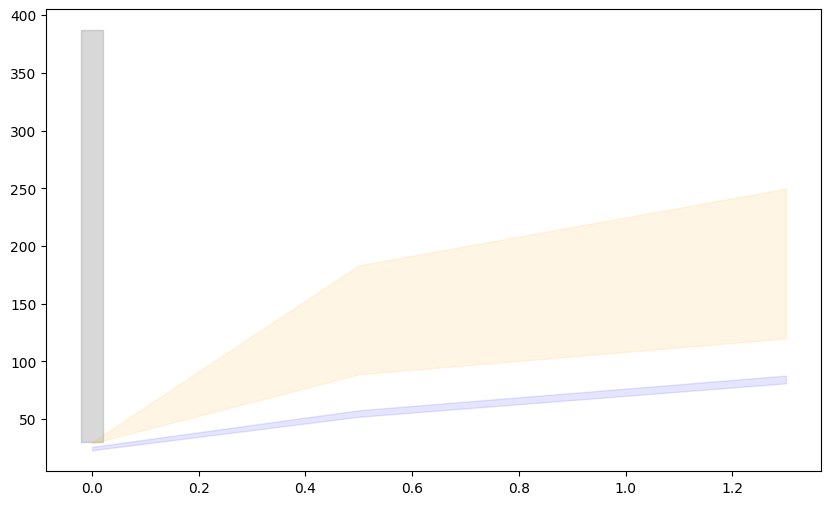

In [5]:
# ============================================================
# Hypothetical Paleo Erosion Calculations
# Run AFTER the hypothetical quartz fertility script
# Uses hypothetical quartz fertility (Qi_9) but ORIGINAL zircon fertility
# Uses: CT_8_synthetic, Qi_9
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

excel_file = '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx'
df = pd.read_excel(excel_file)

# ============================================================
# Paleo erosion rates from CRONUS (unchanged)
# ============================================================
E_c_Ter2_mean = 78.7
E_c_Ter2_std  = 2.8
E_c_Ter10_mean = 51.8
E_c_Ter10_std  = 2.77

# ============================================================
# Hypothetical quartz fertility Q_A/Q_B (CT-8/CT-3)
# ============================================================
i_f5 = np.where(Qi_9 > 0)
Q_median = np.median(Qi_9[i_f5])
Q_q1     = np.percentile(Qi_9[i_f5], 25)
Q_q3     = np.percentile(Qi_9[i_f5], 75)

print(f"Hypothetical Quartz Fertility Qa/Qb (CT-8_syn/CT-3): {Q_median:.4f} ({Q_q1:.4f} - {Q_q3:.4f})")

# ============================================================
# ORIGINAL zircon fertility Z_A/Z_B (CT-8/CT-3)
# Values from original notebook (Cell 63)
# ============================================================
Z_median = 0.1682
Z_q1     = 0.1175
Z_q3     = 0.2598

print(f"Original Zircon Fertility Za/Zb (CT-8/CT-3): {Z_median:.4f} ({Z_q1:.4f} - {Z_q3:.4f})")

# ============================================================
# Paleo mixing weights from U-Pb unmixing (unchanged)
# ============================================================
w_z1_Ter2 = 0.683   # CT-8
w_z2_Ter2 = 0.317   # CT-3
w_z1_Ter10 = 0.655  # CT-8
w_z2_Ter10 = 0.345  # CT-3

# ============================================================
# Watershed parameters
# ============================================================
sample_a_name = 'CT-8'
sample_b_name = 'CT-3'
sample_c_name = 'CT-9'

A_A = df[df['Sample_ID'] == sample_a_name]['Source_Area'].values[0]
A_B = df[df['Sample_ID'] == sample_b_name]['Source_Area'].values[0]
P_A = df[df['Sample_ID'] == sample_a_name]['Surface_Production_Rate'].values[0]
P_B = df[df['Sample_ID'] == sample_b_name]['Surface_Production_Rate'].values[0]
P_C = df[df['Sample_ID'] == sample_c_name]['Surface_Production_Rate'].values[0]

# ============================================================
# Monte Carlo
# ============================================================
num_samples = 100000
random_seed = 17
np.random.seed(random_seed)

Q_mu = np.log(Q_median)
Q_sig = (np.log(Q_q3) - np.log(Q_q1)) / 1.349
Q_samples = np.random.lognormal(mean=Q_mu, sigma=Q_sig, size=num_samples)

Z_mu = np.log(Z_median)
Z_sig = (np.log(Z_q3) - np.log(Z_q1)) / 1.349
Z_samples = np.random.lognormal(mean=Z_mu, sigma=Z_sig, size=num_samples)

def solve_paleo(E_c_mean, E_c_std, w_z1, w_z2, sample_name):
    """Solve for paleo E_A and E_B"""
    
    E_c = np.random.normal(E_c_mean, E_c_std, size=num_samples)
    Q_ratio = np.random.choice(Q_samples, size=num_samples, replace=True)
    Z_ratio = np.random.choice(Z_samples, size=num_samples, replace=True)
    
    E_A_solutions = np.zeros(num_samples)
    E_B_solutions = np.zeros(num_samples)
    
    for i in range(num_samples):
        k = Z_ratio[i] * (w_z2 / w_z1) * (A_A / A_B)
        numerator = E_c[i] * (A_B * P_B + Q_ratio[i] * A_A * P_A)
        denominator = P_C * (Q_ratio[i] * A_A + A_B * k)
        
        if denominator > 0 and numerator > 0:
            E_A_solutions[i] = numerator / denominator
            E_B_solutions[i] = k * E_A_solutions[i]
        else:
            E_A_solutions[i] = np.nan
            E_B_solutions[i] = np.nan

    valid = (E_A_solutions > 0) & (E_B_solutions > 0) & ~np.isnan(E_A_solutions)
    E_A_valid = E_A_solutions[valid]
    E_B_valid = E_B_solutions[valid]
    
    print(f"\n{sample_name}:")
    print(f"  E_A ({sample_a_name}): {np.median(E_A_valid):.2f} ({np.percentile(E_A_valid, 25):.2f}-{np.percentile(E_A_valid, 75):.2f}) m/Myr")
    print(f"  E_B ({sample_b_name}): {np.median(E_B_valid):.2f} ({np.percentile(E_B_valid, 25):.2f}-{np.percentile(E_B_valid, 75):.2f}) m/Myr")
    print(f"  Valid solutions: {len(E_A_valid)}/{num_samples} ({100*len(E_A_valid)/num_samples:.1f}%)")
    
    return {
        'E_A_median': np.median(E_A_valid),
        'E_B_median': np.median(E_B_valid),
        'E_A_percentiles': (np.percentile(E_A_valid, 25), np.percentile(E_A_valid, 75)),
        'E_B_percentiles': (np.percentile(E_B_valid, 25), np.percentile(E_B_valid, 75)),
        'E_A_samples': E_A_valid,
        'E_B_samples': E_B_valid
    }

print("\nHYPOTHETICAL PALEO EROSION RATES (original zircon, hypothetical quartz)")
results_Ter2 = solve_paleo(E_c_Ter2_mean, E_c_Ter2_std, w_z1_Ter2, w_z2_Ter2, 'CT-Ter-2')
results_Ter10 = solve_paleo(E_c_Ter10_mean, E_c_Ter10_std, w_z1_Ter10, w_z2_Ter10, 'CT-Ter-10')

# ============================================================
# Plot
# Modern E_A is now the synthetic CT-8 rate
# ============================================================
modern_E_A = np.median(CT_8_synthetic)
modern_E_A_std = np.std(CT_8_synthetic)
modern_E_B = df[df['Sample_ID'] == sample_b_name]['Erosion_rate'].values[0]
modern_E_B_std = df[df['Sample_ID'] == sample_b_name]['Erosion_rate_uncertainty_internal'].values[0]

times = [1.30, 0.5, 0.0]

E_A_medians = [results_Ter2['E_A_median'], results_Ter10['E_A_median'], modern_E_A]
E_A_lower = [results_Ter2['E_A_percentiles'][0], results_Ter10['E_A_percentiles'][0], modern_E_A - modern_E_A_std]
E_A_upper = [results_Ter2['E_A_percentiles'][1], results_Ter10['E_A_percentiles'][1], modern_E_A + modern_E_A_std]

E_B_medians = [results_Ter2['E_B_median'], results_Ter10['E_B_median'], modern_E_B]
E_B_lower = [results_Ter2['E_B_percentiles'][0], results_Ter10['E_B_percentiles'][0], modern_E_B - modern_E_B_std]
E_B_upper = [results_Ter2['E_B_percentiles'][1], results_Ter10['E_B_percentiles'][1], modern_E_B + modern_E_B_std]

basin_medians = [78.7, 51.8, 105]
basin_lower = [78.7 - 2.8, 51.8 - 2.77, 105 - 2.01]
basin_upper = [78.7 + 2.8, 51.8 + 2.77, 105 + 2.01]

fig, ax = plt.subplots(figsize=(10, 6))

grey_patch = ax.fill_between([-0.02, 0.02], 29.8, 387, color='grey', alpha=0.3, zorder=0, label='Modern PC range')

ax.fill_between(times, E_A_lower, E_A_upper, color='blue', alpha=0.1, zorder=1)
ax.fill_between(times, E_B_lower, E_B_upper, color='orange', alpha=0.1, zorder=1)
ax.fill_between(times, basin_lower, basin_upper, color='green', alpha=0.1, zorder=1)

ax.plot(times, E_A_medians, '-', color='blue', linewidth=2, zorder=2)
ax.plot(times, E_B_medians, '-', color='orange', linewidth=2, zorder=2)
ax.plot(times, basin_medians, '-', color='green', linewidth=2, zorder=2)

ax.plot(times, E_A_medians, 'o', markersize=10, color='blue', zorder=3, label="Principal Cordillera (Hypothetical)")
ax.plot(times, E_B_medians, 's', markersize=10, color='orange', zorder=3, label="Coastal Cordillera")
ax.plot(times, basin_medians, '^', markersize=10, color='green', zorder=3, label="Basin Average")

offset = 0.01
for t, ea in zip(times, E_A_medians):
    ax.text(t + offset, ea, f' {ea:.1f}', va='center', ha='left', fontsize=9)
for t, eb in zip(times, E_B_medians):
    ax.text(t + offset, eb, f' {eb:.1f}', va='center', ha='left', fontsize=9)
for t, bm in zip(times, basin_medians):
    ax.text(t + offset, bm, f' {bm:.1f}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Time (Ma)')
ax.set_ylabel('Erosion Rate (m/Myr)')
ax.set_title('Hypothetical Paleo Erosion (CT-5 = CT-6 rate, original Zr fertility)')
ax.legend()
plt.grid(True)
plt.show()

print("\nPrincipal Cordillera - Hypothetical (Blue):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, E_A_medians, E_A_lower, E_A_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")

print("\n" + "="*60 + "\n")

print("Coastal Cordillera (Orange):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, E_B_medians, E_B_lower, E_B_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")

print("\n" + "="*60 + "\n")

print("Basin Average (Green):")
print("Time (Ma) | Median (m/Myr) | Lower bound | Upper bound")
print("-" * 60)
for t, med, low, up in zip(times, basin_medians, basin_lower, basin_upper):
    print(f"{t:8.2f} | {med:14.1f} | {low:11.1f} | {up:11.1f}")